## Method: data
1. Load patent data that we saved on patstat (we load the fractonal patents per country per year).

    - Load using pandas
    
    - Check what 2 digit ctry_code there are without ISO3 codes and how many patents they make up and if small drop them

    - Drop year 9999

2. Use the panel_tools to fetch data from WorldBank (and OWID if needed)

3. Merge patent data with panel data
    
    - Check what iso3 codes do not show up in the PANEL data and how many patents they make up
    
    - Drop those countries (i.e. the countries in patent data that do not show up in panel data)

    - Do an outer merge to check for data thats missing to try to reason why its missing

### Loading patent data

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib

_REPO = pathlib.Path("..").resolve()

def raw(subdir):
    return _REPO / "data" / "raw" / subdir

def processed():
    return _REPO / "data" / "processed"

def panel_cache():
    return _REPO / ".panel_cache"

ANALYSIS_START       = 1960
ANALYSIS_END         = 2023
SANCTIONS_FILL_START = 1960
SANCTIONS_FILL_END   = 2023
MIN_PATENTS          = 10
LOOKBACK_WINDOW      = 10

PATENTS_FRAC      = "pf_inv_ctry_year_frac.csv"
PATENTS_Y02       = "pf_inv_ctry_year_frac_any_y.csv"
PATENTS_DIRTY     = "pf_inv_ctry_year_frac_dirty_innovation.csv"
GSDB_DTA          = "GSDB_V4_dyadic.dta"
GSDB_CSV          = "GSDB_V4.csv"
IMF_DOT           = "IMF_DOT_TXG_FOB_USD.csv"
COUNTRY_CODES     = "country.csv"
UNSD_METHODOLOGY  = "UNSD — Methodology.csv"

IMF_SKIP_COUNTRIES  = ["EMU", "WLD", "EUU", "AFR", "SSF"]
IMF_MANUAL_CODE_MAP = {726: "SOM", 546: "MAC", 314: "ABW", 836: "NRU"}
DROP_ISO3           = {"CSK", "YUG", "SVU", "VDR", "DDR", "PSE", "TWN", "SSD", "GNB", "RHO"}

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / "src"))

import pandas as pd
import numpy as np
from sanctions_innovations.patents import load_and_prepare_patents, fill_gaps_of_low_countries

patents_df, missing_codes = load_and_prepare_patents(
    str(raw("patents") / PATENTS_FRAC),
)
print(
    f'Following {len(missing_codes)} country-codes have no iso3 from patstat and have '
    f'{0.0} patents:\n {missing_codes}'
)
idx = pd.IndexSlice
patents_df = patents_df.loc[idx[:, ANALYSIS_START:ANALYSIS_END], :]

patents_df = fill_gaps_of_low_countries(patents_df, min_annual_patents=MIN_PATENTS)


Following 86 country-codes have no iso3 from patstat and have 0.0 patents:
 ['SJ', 'PR', 'VI', 'ZR', 'UM', 'GP', 'CX', 'RE', 'KA', 'PC', 'NC', 'PF', 'UK', 'XK', 'UN', 'GF', 'AS', 'CC', 'TY', 'IO', '97', 'NJ', 'ZJ', 'OH', 'WF', 'CT', 'YS', 'SF', 'PS', 'PN', 'TK', 'UC', 'TP', 'JA', 'MQ', 'UD', 'U', 'NY', 'MI', 'NF', 'RF', 'PI', 'WA', 'RH', 'GU', 'KT', 'JS', 'ON', 'XX', 'FL', 'HW', 'TF', 'AX', 'KS', 'LN', 'UX', 'SP', 'SW', 'TX', 'PO', 'UT', 'NX', 'ZZ', 'FM', 'VZ', 'WV', 'BC', 'NH', 'PM', 'AB', 'XH', 'FA', 'RJ', 'WE', 'TS', 'XA', 'ZH', 'XP', 'S', 'OR', 'RI', 'BL', 'FX', 'UR', 'IA', 'NV']


In [ ]:
patents_df.to_csv(str(processed() / 'raw_patents_panel_1960_2023.csv'))


### Loading panel data

In [44]:
# pyarrow is a project dependency — install via: pip install pyarrow

In [3]:
from sanctions_innovations import WorldBankSource, OWIDGrapherSource, PanelBuilder, FeatureSpec

sources = {
    "wb": WorldBankSource(),
    "owid": OWIDGrapherSource(),
}

features = [
    FeatureSpec(name="gdp_pc_current_usd", source_key="wb", series_code="NY.GDP.PCAP.CD"),
    FeatureSpec(name="gdp_pc_const_2015_usd", source_key="wb", series_code="NY.GDP.PCAP.KD"),
    FeatureSpec(name="trade_pct_gdp", source_key="wb", series_code="NE.TRD.GNFS.ZS"),
    FeatureSpec(name="fdi_net_inflow_pct_gdp", source_key="wb", series_code="BX.KLT.DINV.WD.GD.ZS"),
    FeatureSpec(name="gdp_const_2015_usd", source_key="wb", series_code="NY.GDP.MKTP.KD"),
    FeatureSpec(name="gdp_tot_nominal", source_key="wb", series_code="NY.GDP.MKTP.CD"),
    FeatureSpec(name="population", source_key="wb", series_code="SP.POP.TOTL"),
    FeatureSpec(name="energy_intensity", source_key="wb", series_code="EG.EGY.PRIM.PP.KD"),
    FeatureSpec(name="oil_rents_pct_gdp", source_key="wb", series_code="NY.GDP.PETR.RT.ZS"),
    FeatureSpec(name="gas_rents_pct_gdp", source_key="wb", series_code="NY.GDP.NGAS.RT.ZS"),
    FeatureSpec(name="gdp_const_2015_usd_log", source_key="wb", series_code="NY.GDP.MKTP.KD",
                transform=lambda s: np.log(pd.to_numeric(s, errors="coerce"))),
    FeatureSpec(name="log_gdp_pc_const_2015", source_key="wb", series_code="NY.GDP.PCAP.KD",
                transform=lambda s: np.log(pd.to_numeric(s, errors="coerce"))),
]

pb = PanelBuilder(sources, cache_dir=str(panel_cache()))
panel = pb.build_panel(features)
panel = panel.set_index(['iso3', 'year']).sort_index()


#### Removing iso3 from patent data that are not available in panel data

In [4]:
print('Problematic cases where PANEL data does not contain these IOS3 from PATENT data')
patents_df[~patents_df.index.get_level_values(0).isin(panel.index.get_level_values(0))].groupby('country_name').frac_classical_inv.sum().sort_values().astype(int)[lambda x: x>0]

Problematic cases where PANEL data does not contain these IOS3 from PATENT data


country_name
Niue                                                 1
Western Sahara                                       1
Cook Islands                                         1
Bonaire, Sint Eustatius and Saba                     2
Bouvet Island                                        2
Montserrat                                           3
Saint Helena, Ascension and Tristan da Cunha         7
Guernsey                                             9
Holy See                                            15
Burma                                               18
Anguilla                                            27
Jersey                                             106
Netherlands Antilles                               177
Yugoslavia/Serbia and Montenegro                   744
Czechoslovakia                                    1291
German Democratic Republic                        1855
Soviet Union                                     22570
Taiwan Province of China                        2930

In [5]:
print(f'dropping {patents_df[lambda x: (~x.index.get_level_values(0).isin(panel.index.get_level_values(0)))].frac_classical_inv.sum().round(2)} patents')
reduced_patents_df = patents_df[lambda x: (x.index.get_level_values(0).isin(panel.index.get_level_values(0)))]

dropping 319906.5 patents


#### Checking panel iso3 that are not available in patent

In [6]:
import requests

def get_available_iso3_map(code):    
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}"
    j = requests.get(url, params = {"format": "json", "per_page": 20000}).json()
    return {i['countryiso3code']:i['country']['value'] for i in j[1]}

all_panel_iso3 = get_available_iso3_map('NY.GDP.PCAP.CD')


In [8]:
print('removing the following countries from panel data')
print({i:all_panel_iso3[i] for i in all_panel_iso3 if i not in reduced_patents_df.reset_index().iso3.unique()})
panel = panel[lambda x: x.index.get_level_values(0).isin(reduced_patents_df.reset_index().iso3.unique())]

removing the following countries from panel data
{'AFE': 'Africa Eastern and Southern', 'AFW': 'Africa Western and Central', 'ARB': 'Arab World', 'CSS': 'Caribbean small states', 'CEB': 'Central Europe and the Baltics', 'EAR': 'Early-demographic dividend', 'EAS': 'East Asia & Pacific', 'EAP': 'East Asia & Pacific (excluding high income)', 'TEA': 'East Asia & Pacific (IDA & IBRD countries)', 'EMU': 'Euro area', 'ECS': 'Europe & Central Asia', 'ECA': 'Europe & Central Asia (excluding high income)', 'TEC': 'Europe & Central Asia (IDA & IBRD countries)', 'EUU': 'European Union', 'FCS': 'Fragile and conflict affected situations', 'HPC': 'Heavily indebted poor countries (HIPC)', '': 'Upper middle income', 'IBD': 'IBRD only', 'IBT': 'IDA & IBRD total', 'IDB': 'IDA blend', 'IDX': 'IDA only', 'IDA': 'IDA total', 'LTE': 'Late-demographic dividend', 'LCN': 'Latin America & Caribbean', 'LAC': 'Latin America & Caribbean (excluding high income)', 'TLA': 'Latin America & the Caribbean (IDA & IBRD cou

#### Merging panel and patents (outer) and checking for issues

In [9]:
panel_with_patents = pd.concat(
    [panel,  reduced_patents_df[['frac_classical_inv']]],
    axis=1
    )
panel_with_patents.index.names = ['iso3', 'year']
# panel_with_patents.isna().sum()

In [ ]:
panel_with_patents.to_csv(str(processed() / 'patents_panel_1960_2023.csv'))

#### Load Sanctions

### Afesorgbor, 2025

We want to add binary columns that signify whether this country was sanctioned by one of the main SENDERS, similar to Afesorgbor, 2025.

We further quantify export/import sanctions. [Preliminary work]

In [30]:
from sanctions_innovations import SENDERS_ISO3, SENDERS, load_gsdb_data, make_sanction_panel, compute_li_li_index, wb_iso3_map, clean_imf_dot

In [31]:
path = str(raw("sanctions") / GSDB_DTA)

sanctions, gsdb_cases = load_gsdb_data(
    str(raw("sanctions") / GSDB_DTA),
    str(raw("sanctions") / GSDB_CSV),
)
sanctions_og = sanctions.copy()
sanctions = make_sanction_panel(sanctions, senders=SENDERS).sort_index()
sanctions.index.names = ['iso3', 'year']

### Li and Li sanction index

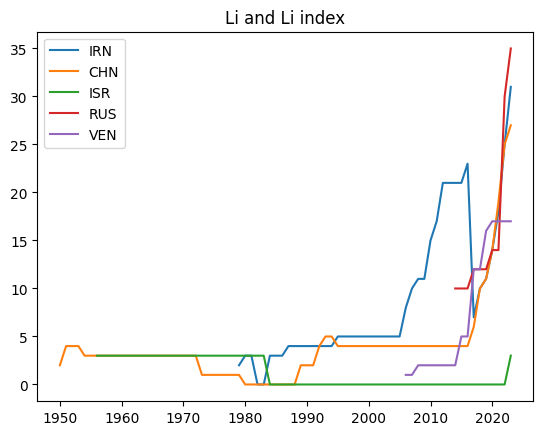

In [34]:
S = compute_li_li_index(gsdb_cases)

sample_countries = ['IRN', 'CHN', 'ISR', 'RUS', 'VEN']
for con in sample_countries:
    S.sum(axis=1).loc[con].plot(title='Li and Li index', label=con, legend=True)

In [35]:
panel_with_patents_sanctions = panel_with_patents.join(sanctions.sort_index(), how='left').assign(
    sanction_index=S.sum(axis=1)
)
# restrict sanctions data to 1960 and later to match the patent data and avoid biasing the threshold with early years where even major patent nations have near-zero counts
panel_with_patents_sanctions = panel_with_patents_sanctions[lambda x: x.index.get_level_values(1)>=1960]

As the GSDB provides data on sanctions for the period 1950–2023, merging it with a broader panel that includes data from other sources with different time spans yields observations outside the GSDB’s coverage window. For years outside 1950–2023, sanction values remain missing (NaN), since the GSDB does not provide information for those years. The GSDB reports only sanction episodes that occurred and is assumed to be comprehensive. Therefore, if a country–year does not appear in the GSDB within the 1950–2023 period, it is interpreted as having no sanction episode, and missing country–year values during this period are filled with zeros.

In [36]:
fill_zero_mask = (panel_with_patents_sanctions.index.get_level_values(1) >= 1950) & (panel_with_patents_sanctions.index.get_level_values(1) <= 2023)
for col in sanctions:
    panel_with_patents_sanctions[col] = panel_with_patents_sanctions[col].fillna(0).where(fill_zero_mask)

In [37]:
# world bank categories for income
r = requests.get("https://api.worldbank.org/v2/country?format=json&per_page=2000")

world_bank_categories = pd.DataFrame.from_dict(
    {i['id']:(i['region']['value'], i['incomeLevel']['value']) for i in r.json()[1]},
    orient='index',
    columns=['region', 'income_level']
    )[lambda x: x.region!='Aggregates']


In [38]:
un_categories = pd.read_csv(str(raw("reference") / UNSD_METHODOLOGY), delimiter=';').drop(
    ['Global Code', 'Global Name',
     'Intermediate Region Code', 'Intermediate Region Name',
     'M49 Code', 'ISO-alpha2 Code'],
    axis=1
    ).set_axis(['region_code', 'region_name', 'sub_region_code', 'sub_region_name', 'country', 'iso3', 'ldc', 'lldc', 'sids'], axis=1)

for c in ['ldc', 'lldc', 'sids']:
    un_categories[c] = un_categories[c].replace('x',True).fillna(False)
    
un_categories = un_categories.set_index('iso3')[lambda x: x.country!='Antarctica']

for s in SENDERS_ISO3:
    un_categories.loc[list(SENDERS_ISO3[s]), f'in_{s}'] = True

un_categories.fillna(False, inplace=True)
un_categories['income_level'] = world_bank_categories.income_level

In [39]:
panel_with_patents_sanctions.index.rename(['iso3', 'year'], inplace=True)
panel_with_patents_sanctions = panel_with_patents_sanctions.join(un_categories, on='iso3')

In [40]:
#import pf_inv_ctry_year_frac_y.csv as a dataframe named y_patents_df with index iso3 and priority_year
y02_patents_panel = pd.read_csv(str(raw("patents") / PATENTS_Y02))

y02_cols = [
    "frac_y02a","frac_y02b","frac_y02c","frac_y02d","frac_y02e",
    "frac_y02p","frac_y02t","frac_y02w"
]

# y02_patents_panel["sum_y02_patents"] = y02_patents_panel[y02_cols].sum(axis=1)
y02_patents_panel["sum_y02_patents"] = y02_patents_panel["frac_y02_any"]

patent_fractions_summary_df = y02_patents_panel.drop(columns=y02_cols)

In [41]:
import pycountry

def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

y02_df = patent_fractions_summary_df.copy()

y02_df["iso3"] = y02_df["ctry_code"].apply(iso2_to_iso3)

y02_df = y02_df.dropna(subset=["iso3"]).set_index(["iso3", "priority_year"])
y02_df.index = y02_df.index.set_names(["iso3", "year"])


panel_df = panel_with_patents_sanctions.copy()


cols_to_add = ["frac_y04s", "sum_y02_patents"]

final_panel_with_patents_sanctions = panel_df.join(
    y02_df[cols_to_add],
    how="left"
)

In [42]:
#import pf_inv_ctry_year_frac_y.csv as a dataframe named y_patents_df with index iso3 and priority_year
dirty_panel = pd.read_csv(str(raw("patents") / PATENTS_DIRTY))
dirty_panel["iso3"] = dirty_panel["ctry_code"].apply(iso2_to_iso3)
dirty_panel = dirty_panel.rename(columns={'priority_year': 'year'}).set_index(['iso3', 'year'])
final_panel_with_patents_sanctions = final_panel_with_patents_sanctions.join(
    dirty_panel[['frac_dirty_innovation']],
    how="left",
)

In [43]:
# # 1. Count non-missing entries
# non_nan_count = final_panel_with_patents_sanctions["sum_y02_patents"].notna().sum()
# print("Number of non-NaN green patent entries:", non_nan_count)

# # 2. Extract only the rows with real data on green patents
# non_nan_green = final_panel_with_patents_sanctions[
#     final_panel_with_patents_sanctions["sum_y02_patents"].notna()
# ]

# print("\nRows with green-patent data:")
# display(non_nan_green.head())

# # 3. Summary statistics
# print("\nSummary of green-patent values:")
# print(non_nan_green["sum_y02_patents"].describe())

# # 4. Countries that have at least one green-patent entry
# countries_with_green = (
#     non_nan_green
#     .groupby(level="iso3")
#     .size()
#     .sort_values(ascending=False)
# )

# print("\nCountries with green-patent data (counts of years):")
# print(countries_with_green.head(20))


In [44]:
# Mask: classical patents exist AND green patents are missing
mask = (
    final_panel_with_patents_sanctions["frac_classical_inv"].notna() &
    final_panel_with_patents_sanctions["sum_y02_patents"].isna()
)

# Number of rows affected
print("Rows to update:", mask.sum())

# Set green patents to 0 for those rows
final_panel_with_patents_sanctions.loc[mask, "sum_y02_patents"] = 0

# Check if any problem rows remain
remaining = final_panel_with_patents_sanctions[
    final_panel_with_patents_sanctions["frac_classical_inv"].notna() &
    final_panel_with_patents_sanctions["sum_y02_patents"].isna()
]

print("Remaining problematic rows:", remaining.shape[0])



Rows to update: 2503
Remaining problematic rows: 0


In [45]:
final_panel_with_patents_sanctions.to_csv(
    str(processed() / 'final_panel_with_y_02_patents_sanctions_final.csv'), index=True
)

In [47]:
IMF_DOT_CSV = str(raw("trade") / IMF_DOT)

imf_dot_df = pd.read_csv(IMF_DOT_CSV)
name = wb_iso3_map()
code_to_iso3 = pd.read_csv(str(raw("reference") / COUNTRY_CODES)).set_index('WEO').ISO.to_dict()
code_to_iso3 |= IMF_MANUAL_CODE_MAP

imf_dot_df_red = clean_imf_dot(
    imf_dot_df,
    name_to_iso3=name,
    code_to_iso3=code_to_iso3,
    skip_countries=IMF_SKIP_COUNTRIES,
)

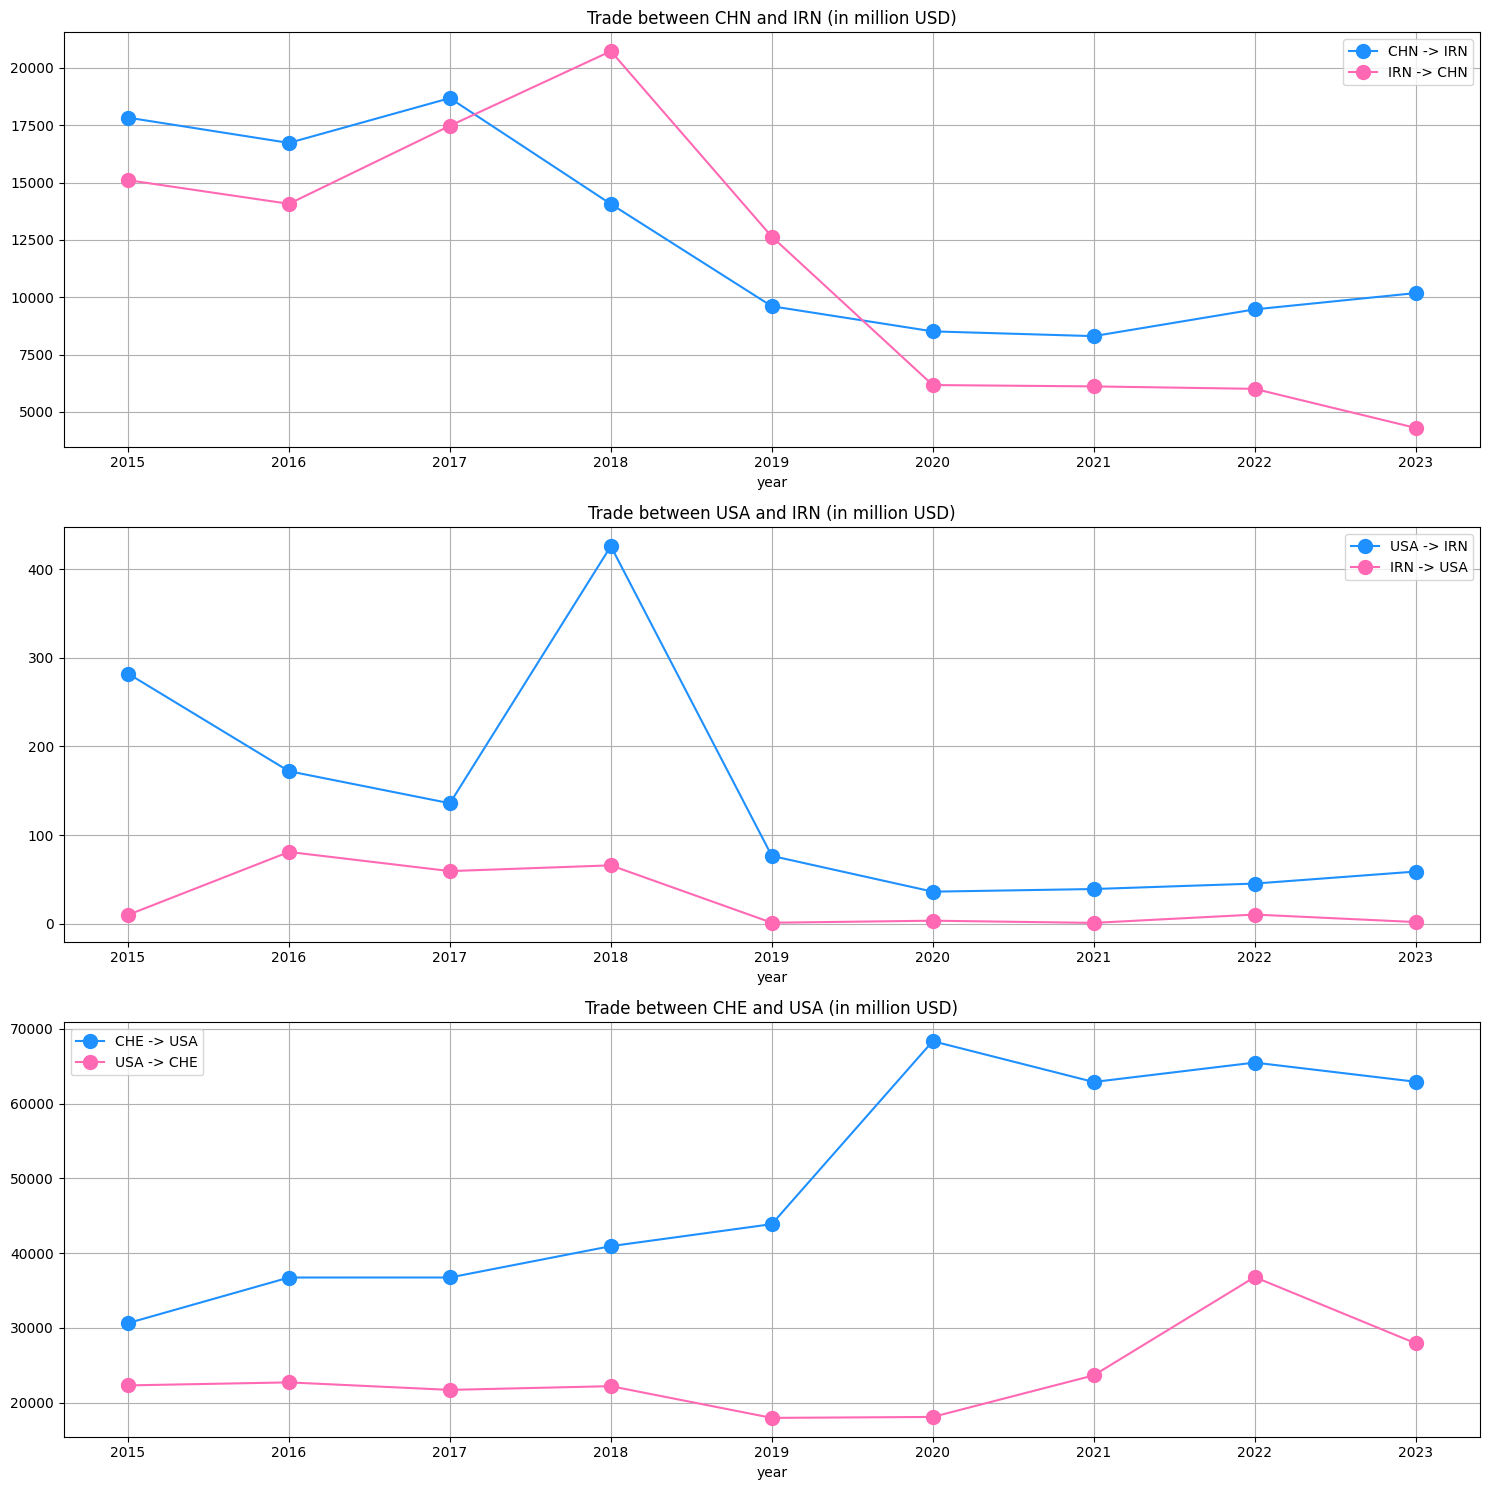

In [49]:
import matplotlib.pyplot as plt
pairs = [
    ('CHN', 'IRN'),
    ('USA', 'IRN'),
    ('CHE', 'USA'),
]
start = 2015
end = 2030

fig, ax = plt.subplots(len(pairs), 1, figsize=(15,5*len(pairs)))
for i, (c1, c2) in enumerate(pairs):
    (imf_dot_df_red.set_index('year').sort_index().loc[start: end][lambda x: (x.iso3==c1) & (x.counterparty_iso3==c2)].obs_value/1e6).plot(ax=ax[i], label=f'{c1} -> {c2}', grid=True, marker='.', c='dodgerblue', markersize=20)
    (imf_dot_df_red.set_index('year').sort_index().loc[start: end][lambda x: (x.iso3==c2) & (x.counterparty_iso3==c1)].obs_value/1e6).plot(ax=ax[i], label=f'{c2} -> {c1}', grid=True, marker='.', c='hotpink', markersize=20)
    ax[i].set_title(f'Trade between {c1} and {c2} (in million USD)')
    ax[i].legend()
    
    
plt.tight_layout()

/var/folders/h2/rhnjf6l54z71_g75dgncdsbc0000gn/T/ipykernel_61366/1231746022.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/h2/rhnjf6l54z71_g75dgncdsbc0000gn/T/ipykernel_61366/1231746022.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


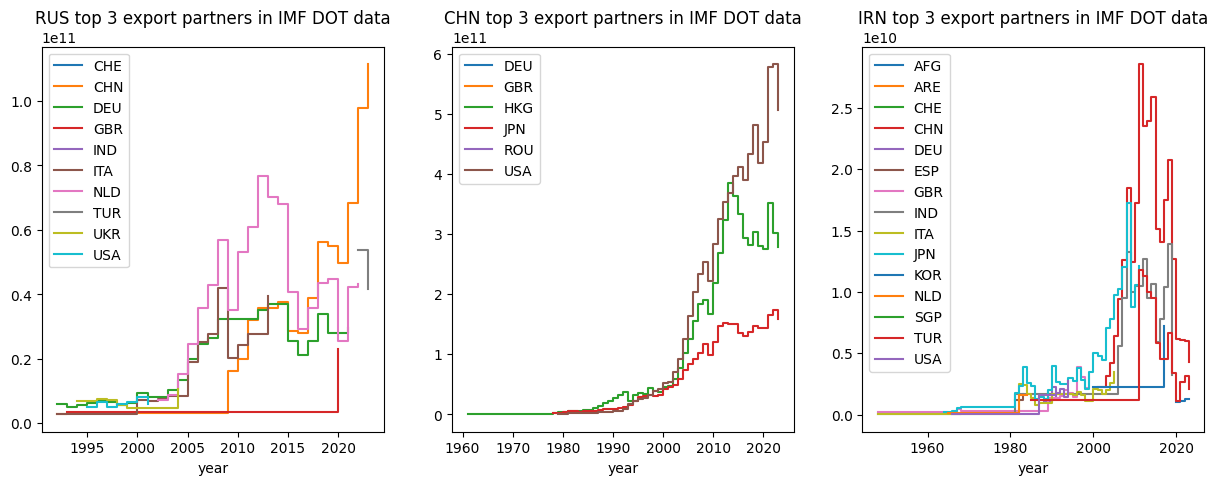

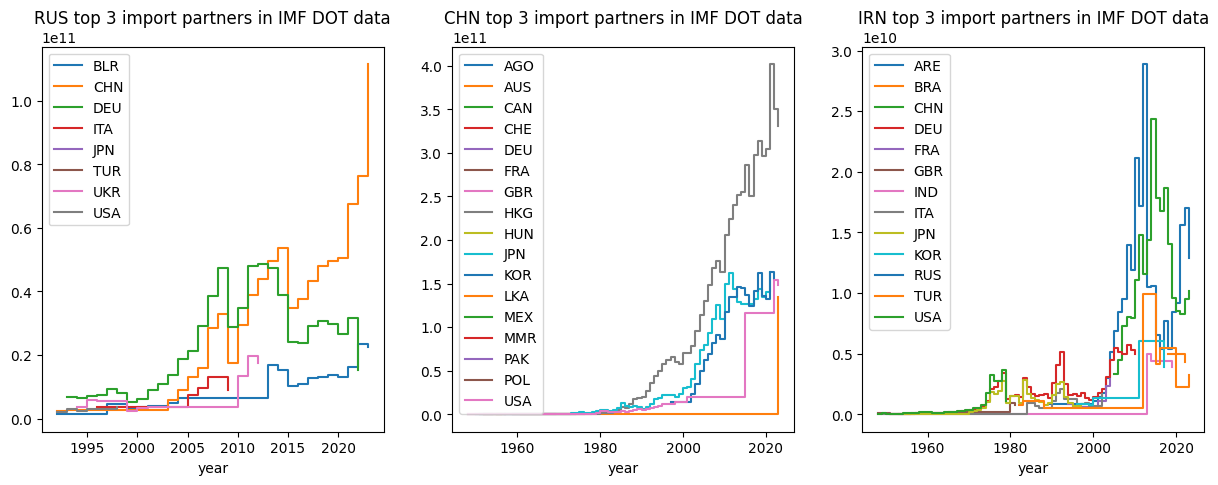

In [55]:
countries = ['RUS' ,'CHN', 'IRN']

fig, ax = plt.subplots(1, len(countries), figsize=(15,5))
for i, c in  enumerate(countries):
    for cc, d in imf_dot_df_red[lambda x: x.iso3==c].assign(
        rank_per_year=lambda x: x.groupby('year').obs_value.rank(method='min', ascending=False)
        )[lambda x: x.rank_per_year<=3].set_index('year').sort_index().groupby('counterparty_iso3'):
        
        d.obs_value.plot(label=cc, ax=ax[i], title=f'{c} top 3 export partners in IMF DOT data',legend=True, drawstyle='steps-post')
fig.show()

fig, ax = plt.subplots(1, len(countries), figsize=(15,5))
for i, c in  enumerate(countries):
    for cc, d in imf_dot_df_red[lambda x: x.counterparty_iso3==c].assign(
        rank_per_year=lambda x: x.groupby('year').obs_value.rank(method='min', ascending=False)
        )[lambda x: x.rank_per_year<=3].set_index('year').sort_index().groupby('iso3'):
        d.obs_value.plot(label=cc, ax=ax[i], title=f'{c} top 3 import partners in IMF DOT data',legend=True, drawstyle='steps-post')
fig.show()

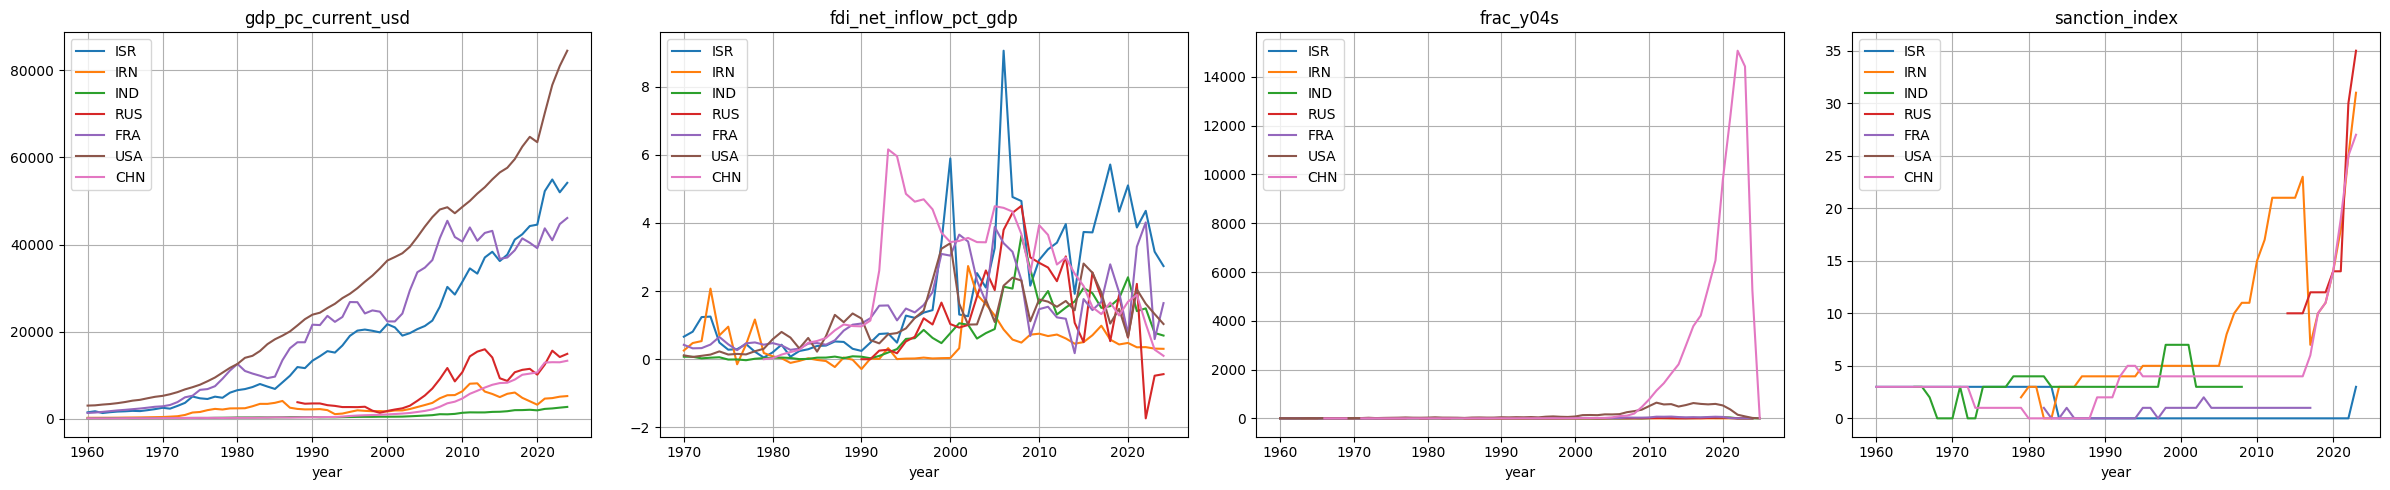

In [56]:
import matplotlib.pyplot as plt

countries = ['ISR',"IRN",'IND','RUS','FRA', 'USA', 'CHN']
metrics = ['gdp_pc_current_usd',"fdi_net_inflow_pct_gdp", 'frac_y04s', 'sanction_index']

fig, ax = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 5))

for i, m in enumerate(metrics):
    for country in countries:
        final_panel_with_patents_sanctions.loc[country].sort_index()[m].plot(label=country, title=m, ax=ax[i], grid=True, legend=True)
plt.tight_layout()